# 06 — National Wage Comparison: Texas Ranks Worst

**Goal:** Show that Texas has the largest HHA/PCA wage gap in the nation, and contextualize
the HHSC wage assumption against 10-year national trends.

**Data Sources:**
- `aspe-dcw-wages-brief.pdf` — ASPE Issue Brief (Dec 2024), Tables A1/A2: state-by-state
  HHA/PCA and CNA wages vs entry-level jobs (BLS OEWS May 2023, 2023$)
- `phi-dcw-key-facts-2025.pdf` — PHI Key Facts 2025: national DCW wage trends 2014-2024
- `bls_oews_texas_2024.csv` — Project BLS data for TX comparison

**Key findings (preview):**
- TX HHA/PCA median: $10.83/hr — the HHSC $10.60 assumption is nearly the market floor
- TX wage gap: $6.77/hr vs entry-level — **largest in the nation** (national avg: $3.73)
- TX HHA/PCAs earn 62 cents per dollar of other entry-level workers
- National DCW median rose $2.98 (2014-2024); TX HHSC assumption was frozen

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from pathlib import Path

from texas_hhcs.verified_datasets import (
    PHI_HOME_CARE_WORKERS, PHI_RESIDENTIAL_CARE_AIDES, PHI_NURSING_ASSISTANTS,
)

PROCESSED = Path('../data/processed')
REPORTS = Path('../reports')

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 120

HHSC_WAGE = 10.60

---
## 1. Texas Has the Largest Wage Gap in the Nation (source_observation)

ASPE Table A1: In 2023, TX HHA/PCAs earned $10.83/hr — $6.77 less than the average
entry-level worker ($17.60). This is the largest gap of all 50 states + DC.

In [2]:
df_aspe = pd.read_csv(PROCESSED / 'aspe_state_dcw_wages.csv')

# Texas position
tx = df_aspe[df_aspe['state'] == 'Texas'].iloc[0]
df_sorted = df_aspe.sort_values('wage_gap', ascending=False)

print("=== Texas HHA/PCA Wage Position (source_observation) ===")
print(f"TX HHA/PCA median wage:     ${tx['median_wage']:.2f}/hr")
print(f"TX avg entry-level wage:    ${tx['avg_entry_level_wage']:.2f}/hr")
print(f"TX wage gap:                ${tx['wage_gap']:.2f}/hr")
print(f"TX wage ratio:              {tx['wage_ratio']:.0%}")
print(f"TX rank (by gap, worst=1):  1 of {len(df_aspe)}")
print(f"\nNational average gap:       $3.73/hr")
print(f"TX gap is {tx['wage_gap'] / 3.73:.1f}x the national average")
print(f"\nNote: HHSC assumes ${HHSC_WAGE}/hr; BLS market is ${tx['median_wage']}/hr")
print(f"  → HHSC assumption is ${tx['median_wage'] - HHSC_WAGE:.2f}/hr BELOW even TX market")

=== Texas HHA/PCA Wage Position (source_observation) ===
TX HHA/PCA median wage:     $10.83/hr
TX avg entry-level wage:    $17.60/hr
TX wage gap:                $6.77/hr
TX wage ratio:              62%
TX rank (by gap, worst=1):  1 of 51

National average gap:       $3.73/hr
TX gap is 1.8x the national average

Note: HHSC assumes $10.6/hr; BLS market is $10.83/hr
  → HHSC assumption is $0.23/hr BELOW even TX market


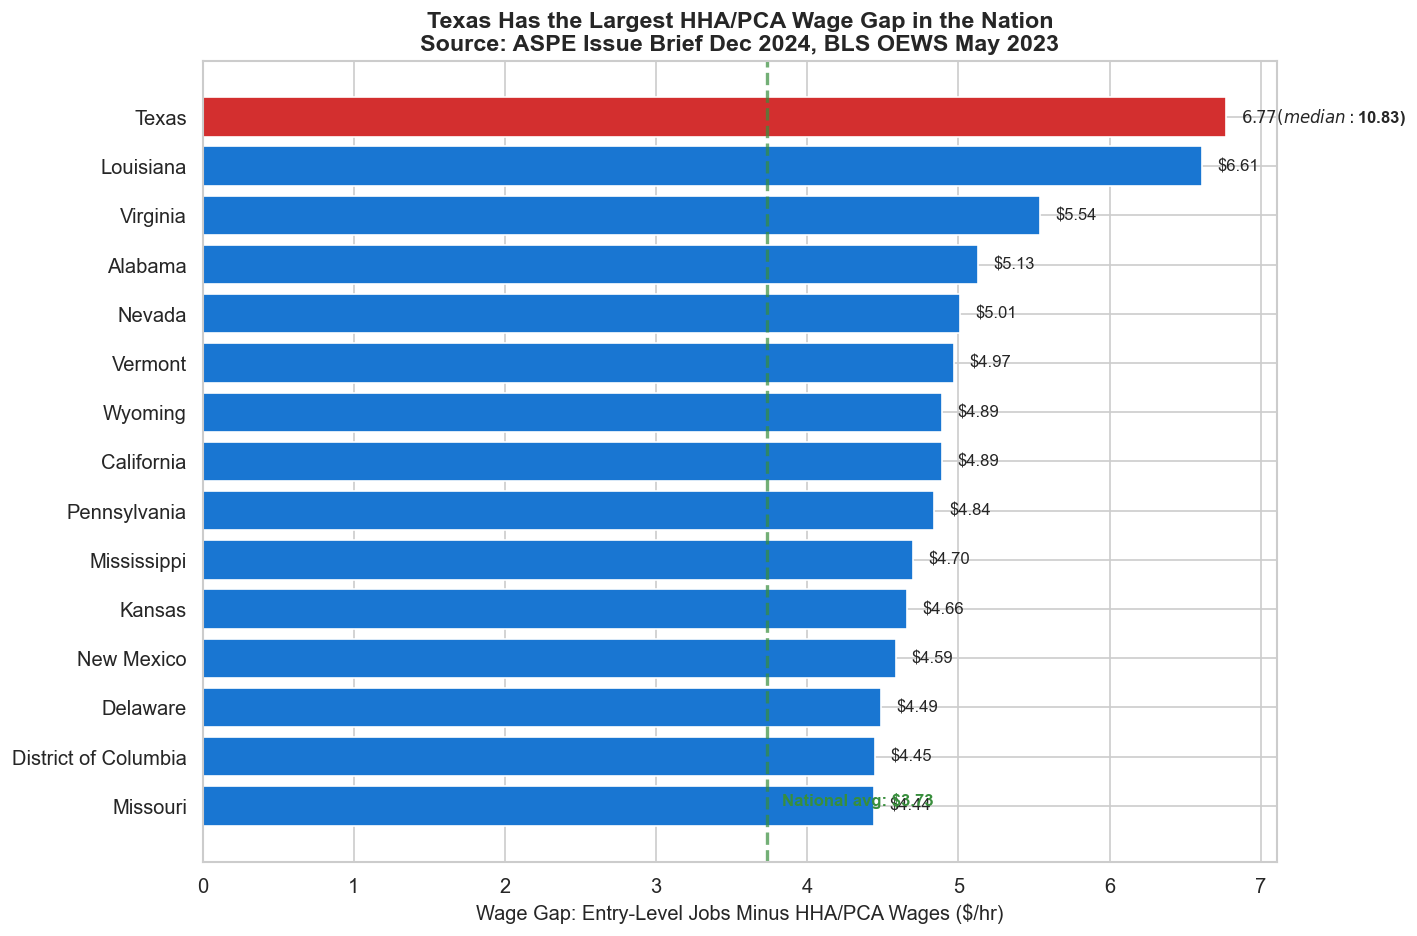

Saved: reports/tx_vs_national_wages.png


In [3]:
# Chart: Top 15 states by wage gap (TX at #1)
fig, ax = plt.subplots(figsize=(12, 8))

top15 = df_sorted.head(15).copy()
colors = ['#d32f2f' if s == 'Texas' else '#1976d2' for s in top15['state']]

bars = ax.barh(range(len(top15)), top15['wage_gap'].values, color=colors, edgecolor='white')
ax.set_yticks(range(len(top15)))
ax.set_yticklabels(top15['state'].values)
ax.invert_yaxis()

for i, (_, row) in enumerate(top15.iterrows()):
    label = f"${row['wage_gap']:.2f}"
    if row['state'] == 'Texas':
        label += f"  (median: ${row['median_wage']:.2f})"
    ax.text(row['wage_gap'] + 0.1, i, label, va='center', fontweight='bold' if row['state'] == 'Texas' else 'normal', fontsize=10)

# National average line
ax.axvline(x=3.73, color='#388e3c', linestyle='--', linewidth=2, alpha=0.7)
ax.text(3.73 + 0.1, 14, 'National avg: $3.73', color='#388e3c', fontsize=10, fontweight='bold')

ax.set_xlabel('Wage Gap: Entry-Level Jobs Minus HHA/PCA Wages ($/hr)', fontsize=12)
ax.set_title('Texas Has the Largest HHA/PCA Wage Gap in the Nation\n'
             'Source: ASPE Issue Brief Dec 2024, BLS OEWS May 2023',
             fontweight='bold', fontsize=14)

plt.tight_layout()
plt.savefig(REPORTS / 'tx_vs_national_wages.png', bbox_inches='tight')
plt.show()
print("Saved: reports/tx_vs_national_wages.png")

---
## 2. National DCW Wage Trends: TX Frozen While Nation Rose (derived_estimate)

PHI data shows national DCW wages rose $2.98/hr (2014-2024).
Overlaying the frozen HHSC $10.60 assumption shows the growing divergence.

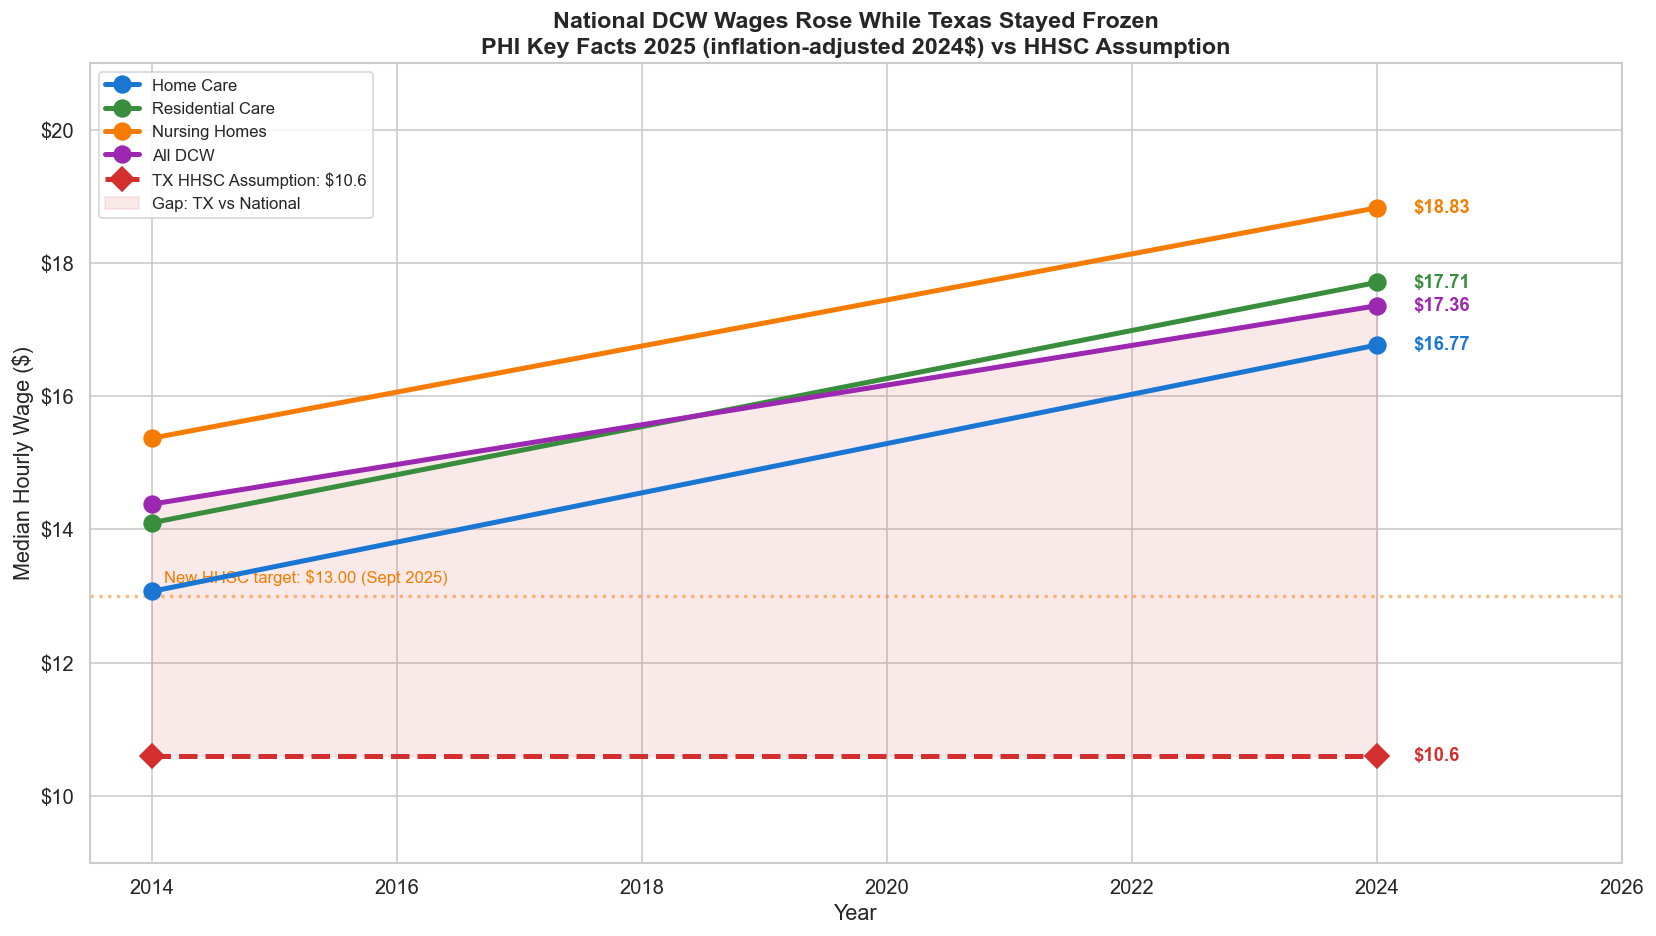


National all-DCW wage increase (2014-2024): $2.98/hr
TX HHSC change over same period: $0.00/hr
Gap in 2024: $6.76/hr

Saved: reports/dcw_wage_trend_decade.png


In [4]:
df_phi = pd.read_csv(PROCESSED / 'phi_national_dcw_wage_trends.csv')

# Reshape for plotting
settings = {
    'home_care': ('Home Care', '#1976d2'),
    'residential_care': ('Residential Care', '#388e3c'),
    'nursing_homes': ('Nursing Homes', '#f57c00'),
    'all_dcw': ('All DCW', '#9c27b0'),
}

fig, ax = plt.subplots(figsize=(14, 8))

for setting, (label, color) in settings.items():
    data = df_phi[df_phi['setting'] == setting].sort_values('year')
    ax.plot(data['year'], data['median_wage'], 'o-', color=color,
            linewidth=3, markersize=10, label=f'{label}', zorder=4)
    # Label 2024 value
    w2024 = data[data['year'] == 2024]['median_wage'].iloc[0]
    ax.text(2024.3, w2024, f'${w2024:.2f}', color=color, fontweight='bold', fontsize=11, va='center')

# HHSC frozen wage
ax.plot([2014, 2024], [HHSC_WAGE, HHSC_WAGE], 'D--', color='#d32f2f',
        linewidth=3, markersize=10, label=f'TX HHSC Assumption: ${HHSC_WAGE}', zorder=5)
ax.text(2024.3, HHSC_WAGE, f'${HHSC_WAGE}', color='#d32f2f', fontweight='bold', fontsize=11, va='center')

# New $13 line
ax.axhline(y=13.00, color='#f57c00', linestyle=':', alpha=0.5, linewidth=2)
ax.text(2014.1, 13.2, 'New HHSC target: $13.00 (Sept 2025)', color='#f57c00', fontsize=10)

# Fill gap between HHSC and national all-DCW
all_dcw_2014 = df_phi[(df_phi['setting'] == 'all_dcw') & (df_phi['year'] == 2014)]['median_wage'].iloc[0]
all_dcw_2024 = df_phi[(df_phi['setting'] == 'all_dcw') & (df_phi['year'] == 2024)]['median_wage'].iloc[0]
ax.fill_between([2014, 2024], [HHSC_WAGE, HHSC_WAGE], [all_dcw_2014, all_dcw_2024],
                alpha=0.1, color='#d32f2f', label='Gap: TX vs National')

ax.set_xlabel('Year', fontsize=13)
ax.set_ylabel('Median Hourly Wage ($)', fontsize=13)
ax.set_title('National DCW Wages Rose While Texas Stayed Frozen\n'
             'PHI Key Facts 2025 (inflation-adjusted 2024$) vs HHSC Assumption',
             fontweight='bold', fontsize=14)
ax.legend(fontsize=10, loc='upper left')
ax.set_ylim(9, 21)
ax.set_xlim(2013.5, 2026)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:.0f}'))

plt.tight_layout()
plt.savefig(REPORTS / 'dcw_wage_trend_decade.png', bbox_inches='tight')
plt.show()

print(f"\nNational all-DCW wage increase (2014-2024): ${all_dcw_2024 - all_dcw_2014:.2f}/hr")
print(f"TX HHSC change over same period: $0.00/hr")
print(f"Gap in 2024: ${all_dcw_2024 - HHSC_WAGE:.2f}/hr")
print(f"\nSaved: reports/dcw_wage_trend_decade.png")

---
## 3. Regional Comparison: TX vs Neighboring States (source_observation)

How does Texas compare to its neighbors and similar-sized states?

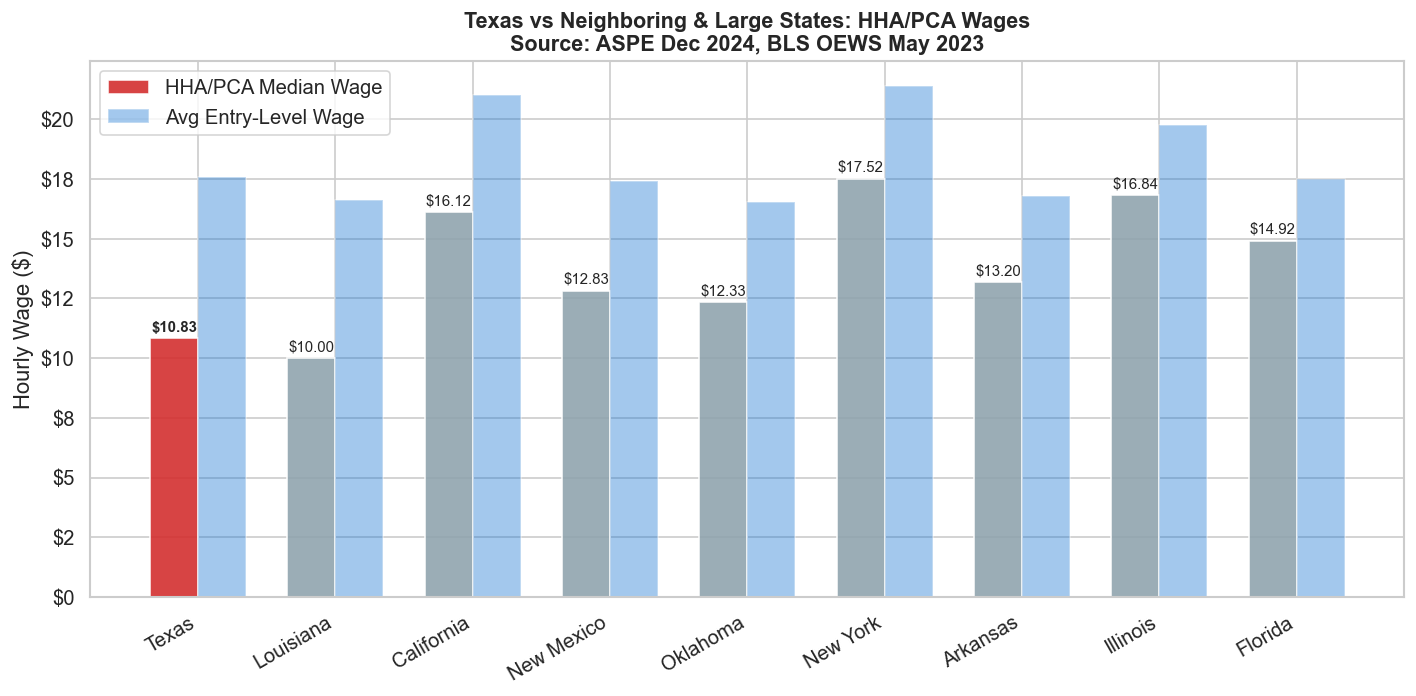


Regional comparison (source_observation):
  Texas                $10.83  gap $ 6.77  ratio 62% ← WORST
  Louisiana            $10.00  gap $ 6.61  ratio 60%
  California           $16.12  gap $ 4.89  ratio 77%
  New Mexico           $12.83  gap $ 4.59  ratio 74%
  Oklahoma             $12.33  gap $ 4.22  ratio 74%
  New York             $17.52  gap $ 3.86  ratio 82%
  Arkansas             $13.20  gap $ 3.58  ratio 79%
  Illinois             $16.84  gap $ 2.94  ratio 85%
  Florida              $14.92  gap $ 2.59  ratio 85%


In [5]:
# Regional and large-state comparison
compare_states = [
    'Texas', 'Louisiana', 'Oklahoma', 'New Mexico', 'Arkansas',
    'California', 'Florida', 'New York', 'Illinois',
]
df_compare = df_aspe[df_aspe['state'].isin(compare_states)].copy()
df_compare = df_compare.sort_values('wage_gap', ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))

colors = ['#d32f2f' if s == 'Texas' else '#90a4ae' for s in df_compare['state']]

x = np.arange(len(df_compare))
width = 0.35
ax.bar(x - width/2, df_compare['median_wage'].values, width,
       label='HHA/PCA Median Wage', color=colors, alpha=0.9)
ax.bar(x + width/2, df_compare['avg_entry_level_wage'].values, width,
       label='Avg Entry-Level Wage', color='#1976d2', alpha=0.4)

for i, (_, r) in enumerate(df_compare.iterrows()):
    ax.text(i - width/2, r['median_wage'] + 0.3, f"${r['median_wage']:.2f}",
            ha='center', fontsize=9, fontweight='bold' if r['state'] == 'Texas' else 'normal')

ax.set_xticks(x)
ax.set_xticklabels(df_compare['state'].values, rotation=30, ha='right')
ax.set_ylabel('Hourly Wage ($)')
ax.set_title('Texas vs Neighboring & Large States: HHA/PCA Wages\n'
             'Source: ASPE Dec 2024, BLS OEWS May 2023',
             fontweight='bold', fontsize=13)
ax.legend()
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f'${v:.0f}'))

plt.tight_layout()
plt.show()

print("\nRegional comparison (source_observation):")
for _, r in df_compare.iterrows():
    ratio = r['wage_ratio'] * 100
    flag = " ← WORST" if r['state'] == 'Texas' else ""
    print(f"  {r['state']:<20} ${r['median_wage']:>5.2f}  "
          f"gap ${r['wage_gap']:>5.2f}  ratio {ratio:.0f}%{flag}")

---
## 4. Key Findings

| Finding | Value | Type | Source |
|---------|-------|------|--------|
| TX HHA/PCA median wage | $10.83/hr | source_observation | ASPE Dec 2024, Table A1 |
| TX wage gap vs entry-level | $6.77/hr — **largest in nation** | source_observation | ASPE Dec 2024, Table A1 |
| TX wage ratio | 62% of entry-level | source_observation | ASPE Dec 2024, Table A1 |
| TX gap vs national avg gap | 1.8x ($6.77 vs $3.73) | derived_estimate | ASPE Table A1 calculation |
| HHSC assumption vs TX market | $0.23/hr below even TX median | derived_estimate | $10.83 - $10.60 |
| National home care median (2024) | $16.77/hr | source_observation | PHI Key Facts 2025 |
| National all-DCW median (2024) | $17.36/hr | source_observation | PHI Key Facts 2025 |
| National DCW wage growth (2014-2024) | +$2.98/hr | derived_estimate | PHI 2014 vs 2024 |
| TX HHSC wage growth (2014-2024) | $0.00/hr | source_observation | HHSC PFD Wage Calculator |

**Bottom line:** Texas pays its HHA/PCAs less relative to other entry-level workers than
any other state. The HHSC $10.60 assumption was not only frozen for a decade — it was
*already below the Texas market floor*. Even the new $13.00 target remains $3.77/hr below
the 2024 national home care median and $4.36/hr below the all-DCW median.